# From Full Fine-tuning to LoRA

Last week you built GPT-2 from scratch and fine-tuned it. You have a working model of the loss, the optimizer, and the training loop. Today:

The bottleneck turns out to be the optimizer — specifically, **AdamW** — so we'll start there. Once we understand *why* AdamW costs what it costs, LoRA will fall out as a natural response: "keep AdamW, but, apply it to far fewer parameters." Then we'll prove the idea works by LoRA-fine-tuning a real ~1.5B-parameter LLM (Qwen 2.5 1.5B-Instruct by default; Llama 3.2 1B-Instruct as an option) on a real task.

## Prerequisites

- A CUDA GPU with **≥ 8 GB** of memory. Qwen 2.5 1.5B in bf16 is ~3 GB; LoRA training peaks around 6 GB. The notebook will run on CPU but Part 3 training will be slow.
- `pip install -U torch transformers peft datasets accelerate huggingface_hub hf_xet`
- For the optional Llama 3.2 path: a Hugging Face account with the license accepted at <https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct>, and `huggingface-cli login` run once. **The default model in Part 3 is the ungated Qwen 2.5 1.5B-Instruct** so the notebook works without any HF authentication.

## Part 0 — Setup

In [2]:
# Workaround for a version mismatch between huggingface_hub and hf_xet
# that produces:  download_files() got an unexpected keyword argument 'request_headers'
# This MUST be set before any transformers / huggingface_hub import.
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

import gc
import time
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch:        {torch.__version__}")
print(f"Device:         {device}")
if device.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU:            {p.name}")
    print(f"Total memory:   {p.total_memory/1e9:.1f} GB")
else:
    print("Running on CPU. Part 1 will work but be slow; Part 3 (Llama/Qwen training) is impractical without a GPU.")

PyTorch:        2.10.0+cu128
Device:         cuda
GPU:            NVIDIA A100-SXM4-40GB
Total memory:   42.4 GB


In [3]:
def reset_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def report_memory(label):
    if torch.cuda.is_available():
        peak = torch.cuda.max_memory_allocated() / 1e9
        print(f"[{label}] peak GPU memory: {peak:.2f} GB")

## Part 1 — AdamW: the default, and what it costs you

### 1.1 Why AdamW dominates transformer training

For nearly every transformer trained in the last 5 years — GPT, BERT, Llama, Mistral, Qwen — the optimizer is AdamW. Why?

**The good:**

- **Per-parameter adaptive learning rates.** AdamW keeps a running estimate of the gradient mean (`m`) and squared gradient (`v`) for every parameter. The effective step size is roughly `lr · m / sqrt(v)`. Parameters with consistently large gradients get smaller effective steps; parameters with tiny gradients get amplified. This robustness is what lets you train a 70B model with one set of hyperparameters across all layers.
- **Decoupled weight decay** (this is the "W" in AdamW). Original Adam baked weight decay into the gradient, which interacted badly with the adaptive scaling. Loshchilov & Hutter (2017) showed that decoupling — applying weight decay directly to the parameter, separate from the gradient — fixes generalization. AdamW = Adam + that fix.
- **Robustness.** AdamW with `lr=1e-4`, `β1=0.9`, `β2=0.95`, `weight_decay=0.1` works for basically any transformer. You don't have to tune.

**The cost:**

- **Memory.** AdamW stores two extra fp32 buffers per parameter (`m` and `v`). That's 8 bytes per parameter, on top of the parameter itself.
- A small amount of extra compute per step (negligible compared to the forward/backward).

That second point — the memory — is the one that bites at scale. Let's quantify.

In [4]:
def static_memory_gb(num_params, weight_bytes=2, grad_bytes=2, optim_bytes=8):
    """Static training memory in GB. Defaults: bf16 weights/grads, AdamW with fp32 m, v."""
    w = num_params * weight_bytes / 1e9
    g = num_params * grad_bytes   / 1e9
    o = num_params * optim_bytes  / 1e9
    return {"weights": w, "grads": g, "optim": o, "total": w + g + o}

# Quick sanity check on common LLM sizes:
for params_b, name in [(1, "Llama-3.2-1B"), (8, "Llama-3-8B"), (70, "Llama-3-70B")]:
    m = static_memory_gb(params_b * 1e9)
    print(f"{name:14s} | weights {m['weights']:6.1f} | grads {m['grads']:6.1f} "
          f"| AdamW {m['optim']:6.1f} | total {m['total']:6.1f} GB")

Llama-3.2-1B   | weights    2.0 | grads    2.0 | AdamW    8.0 | total   12.0 GB
Llama-3-8B     | weights   16.0 | grads   16.0 | AdamW   64.0 | total   96.0 GB
Llama-3-70B    | weights  140.0 | grads  140.0 | AdamW  560.0 | total  840.0 GB


**Read the table.** For Llama-3-8B, AdamW state alone is **64 GB** — already more than an A100 80 GB has after activations. For 70B, it's 560 GB of optimizer state alone. Without intervention, AdamW prices large models out of single-GPU training.

### 1.2 Optimizer alternatives

There are essentially three escape routes from AdamW's memory cost. They're all worth knowing.

| Optimizer        | State per param | Notes                                                                       |
|------------------|-----------------|-----------------------------------------------------------------------------|
| SGD              | 0 B             | Doesn't train transformers reliably. Loss curves are dramatically worse.    |
| SGD + momentum   | 4 B             | Same problem.                      |
| AdamW (mixed)    | 8 B             | The default. fp32 m and v.                                                  |


A more strategic option — and the one this class is about — is to **leave AdamW alone but apply it to far fewer parameters.** That's LoRA.

### 1.3 Empirical check — SGD vs AdamW on a small fine-tune

Before we move on, let's make the AdamW-vs-SGD claim concrete. We'll fine-tune GPT-2 small with each, on the same data, and look at the loss curves.

In [7]:
DATA = [
    # Geography
    {"instruction": "What is the capital of France?",                 "response": "The capital of France is Paris."},
    {"instruction": "What is the capital of Japan?",                  "response": "Tokyo is the capital of Japan."},
    {"instruction": "What is the largest country by area?",           "response": "Russia is the largest country in the world by area, covering about 17.1 million square kilometers."},
    {"instruction": "What is the longest river in the world?",        "response": "The Nile is traditionally considered the longest river, at about 6,650 km."},
    {"instruction": "Which continent has the most countries?",        "response": "Africa has the most countries of any continent, with 54 recognized states."},
    {"instruction": "Name the five Great Lakes.",                     "response": "The five Great Lakes are Superior, Michigan, Huron, Erie, and Ontario."},
    {"instruction": "What ocean lies between Africa and Australia?",  "response": "The Indian Ocean lies between Africa and Australia."},
    {"instruction": "What is the highest mountain in Africa?",        "response": "Mount Kilimanjaro in Tanzania is the highest mountain in Africa."},
    {"instruction": "What city is known as the Eternal City?",        "response": "Rome is known as the Eternal City."},
    {"instruction": "What is the smallest country in the world?",     "response": "Vatican City is the smallest country, with an area of about 0.49 square kilometers."},

    # Math
    {"instruction": "What is 13 times 17?",                           "response": "13 times 17 equals 221."},
    {"instruction": "What is the square root of 144?",                "response": "The square root of 144 is 12."},
    {"instruction": "Solve for x: 2x + 5 = 13.",                      "response": "Subtracting 5 from both sides gives 2x = 8, so x = 4."},
    {"instruction": "What is the area of a circle with radius 4?",    "response": "The area is pi times r squared, which is 16 pi, approximately 50.27."},
    {"instruction": "What is the next prime number after 23?",        "response": "The next prime number after 23 is 29."},
    {"instruction": "Convert 5/8 to a decimal.",                      "response": "5 divided by 8 equals 0.625."},
    {"instruction": "What is 15 percent of 200?",                     "response": "15 percent of 200 is 30."},
    {"instruction": "How many degrees are in a triangle?",            "response": "The interior angles of a triangle always sum to 180 degrees."},
    {"instruction": "What is 2 to the 10th power?",                   "response": "2 to the 10th power is 1024."},
    {"instruction": "What is the value of pi to two decimal places?", "response": "Pi is approximately 3.14."},

    # Science
    {"instruction": "What is the chemical symbol for gold?",          "response": "The chemical symbol for gold is Au, from the Latin aurum."},
    {"instruction": "What gas do plants absorb during photosynthesis?", "response": "Plants absorb carbon dioxide during photosynthesis."},
    {"instruction": "How many bones are in the adult human body?",    "response": "An adult human body contains 206 bones."},
    {"instruction": "What is the speed of light in a vacuum?",        "response": "The speed of light in a vacuum is approximately 299,792,458 meters per second."},
    {"instruction": "Briefly explain photosynthesis.",                "response": "Photosynthesis is the process by which plants convert sunlight, carbon dioxide, and water into glucose and oxygen."},
    {"instruction": "Why does the sky appear blue?",                  "response": "The sky appears blue because shorter blue wavelengths of sunlight scatter more in the atmosphere than longer wavelengths."},
    {"instruction": "What is the largest organ in the human body?",   "response": "The skin is the largest organ in the human body."},
    {"instruction": "How many planets are in our solar system?",      "response": "There are eight planets in our solar system since Pluto was reclassified."},
    {"instruction": "What causes the seasons on Earth?",              "response": "The seasons are caused by Earth's axial tilt of about 23.5 degrees as it orbits the Sun."},
    {"instruction": "What does DNA stand for?",                       "response": "DNA stands for deoxyribonucleic acid."},
    {"instruction": "Name the four states of matter.",                "response": "The four common states of matter are solid, liquid, gas, and plasma."},
    {"instruction": "What is the freezing point of water in Celsius?", "response": "Water freezes at 0 degrees Celsius at standard atmospheric pressure."},

    # History
    {"instruction": "Who was the first president of the United States?", "response": "George Washington was the first president of the United States, serving from 1789 to 1797."},
    {"instruction": "When did World War 2 end?",                      "response": "World War 2 ended in 1945, with Japan's formal surrender in September."},
    {"instruction": "Who wrote the Declaration of Independence?",     "response": "Thomas Jefferson was the principal author of the Declaration of Independence."},
    {"instruction": "Which civilization built the great pyramids of Giza?", "response": "The ancient Egyptians built the great pyramids of Giza around 2500 BCE."},
    {"instruction": "When did humans first walk on the moon?",        "response": "Humans first walked on the moon on July 20, 1969, during the Apollo 11 mission."},
    {"instruction": "Who invented the telephone?",                    "response": "Alexander Graham Bell is credited with inventing the telephone in 1876."},
    {"instruction": "Who was Cleopatra?",                             "response": "Cleopatra VII was the last active ruler of the Ptolemaic Kingdom of Egypt, reigning from 51 to 30 BCE."},
    {"instruction": "When did the Berlin Wall fall?",                 "response": "The Berlin Wall fell on November 9, 1989."},
    {"instruction": "What was the Renaissance?",                      "response": "The Renaissance was a cultural movement in Europe from roughly the 14th to 17th centuries that revived art, science, and classical learning."},
    {"instruction": "Who painted the Sistine Chapel ceiling?",        "response": "Michelangelo painted the Sistine Chapel ceiling between 1508 and 1512."},

    # Literature
    {"instruction": "Who wrote Hamlet?",                              "response": "Hamlet was written by William Shakespeare around 1600."},
    {"instruction": "Who wrote Pride and Prejudice?",                 "response": "Jane Austen wrote Pride and Prejudice, published in 1813."},
    {"instruction": "Name a novel by Toni Morrison.",                 "response": "Beloved is one of Toni Morrison's most celebrated novels."},
    {"instruction": "Who is the author of 1984?",                     "response": "George Orwell wrote the dystopian novel 1984, published in 1949."},
    {"instruction": "Who wrote The Great Gatsby?",                    "response": "F. Scott Fitzgerald wrote The Great Gatsby, published in 1925."},
    {"instruction": "What is a haiku?",                               "response": "A haiku is a traditional Japanese poem with three lines of 5, 7, and 5 syllables."},
    {"instruction": "Who created Sherlock Holmes?",                   "response": "Sir Arthur Conan Doyle created the detective Sherlock Holmes."},
    {"instruction": "Who wrote One Hundred Years of Solitude?",       "response": "Gabriel Garcia Marquez wrote One Hundred Years of Solitude."},

    # Language
    {"instruction": "Translate 'hello' to Spanish.",                  "response": "'Hello' in Spanish is 'hola'."},
    {"instruction": "Translate 'good morning' to French.",            "response": "'Good morning' in French is 'bonjour'."},
    {"instruction": "What does 'carpe diem' mean?",                   "response": "'Carpe diem' is Latin for 'seize the day'."},
    {"instruction": "What is the plural of 'cactus'?",                "response": "The plural of 'cactus' is 'cacti', though 'cactuses' is also accepted."},
    {"instruction": "Define onomatopoeia.",                           "response": "Onomatopoeia is a word that phonetically imitates the sound it describes, like 'buzz' or 'splash'."},
    {"instruction": "Give a synonym for 'happy'.",                    "response": "A synonym for 'happy' is 'joyful', 'cheerful', or 'content'."},
    {"instruction": "Explain the difference between 'affect' and 'effect'.", "response": "'Affect' is usually a verb meaning to influence; 'effect' is usually a noun meaning the result."},
    {"instruction": "What is a metaphor?",                            "response": "A metaphor is a figure of speech that describes something by saying it is something else, without using 'like' or 'as'."},

    # Technology
    {"instruction": "What does CPU stand for?",                       "response": "CPU stands for Central Processing Unit."},
    {"instruction": "Who founded Microsoft?",                         "response": "Microsoft was founded by Bill Gates and Paul Allen in 1975."},
    {"instruction": "What is HTML?",                                  "response": "HTML stands for HyperText Markup Language and is used to structure content on the web."},
    {"instruction": "What is machine learning?",                      "response": "Machine learning is a branch of artificial intelligence in which systems learn patterns from data rather than being explicitly programmed."},
    {"instruction": "What does URL stand for?",                       "response": "URL stands for Uniform Resource Locator."},
    {"instruction": "Who invented the World Wide Web?",               "response": "Tim Berners-Lee invented the World Wide Web in 1989 while working at CERN."},

    # General knowledge
    {"instruction": "Name the largest planet in our solar system.",   "response": "Jupiter is the largest planet in our solar system."},
    {"instruction": "What language is spoken in Brazil?",             "response": "The official language of Brazil is Portuguese."},
    {"instruction": "How many seconds are in an hour?",               "response": "There are 3600 seconds in an hour."},
    {"instruction": "What is the currency of Japan?",                 "response": "The currency of Japan is the yen."},
    {"instruction": "Name the three primary colors of light.",        "response": "The three primary colors of light are red, green, and blue."},
    {"instruction": "Who painted the Mona Lisa?",                     "response": "Leonardo da Vinci painted the Mona Lisa in the early 16th century."},
    {"instruction": "In what year did the Titanic sink?",             "response": "The Titanic sank on April 15, 1912, after striking an iceberg."},
    {"instruction": "What sport is associated with Wimbledon?",       "response": "Wimbledon is the oldest and most prestigious tennis tournament."},
    {"instruction": "How many continents are there?",                 "response": "There are seven continents on Earth."},
    {"instruction": "What is the boiling point of water in Fahrenheit?", "response": "Water boils at 212 degrees Fahrenheit at sea level."},
    {"instruction": "Name the largest mammal.",                       "response": "The blue whale is the largest mammal, reaching up to 30 meters in length."},
    {"instruction": "What is the tallest building in the world?",     "response": "The Burj Khalifa in Dubai is the tallest building in the world, at 828 meters."},
    {"instruction": "What is the most spoken language in the world?", "response": "Mandarin Chinese has the most native speakers; English has the most total speakers including non-native ones."},
    {"instruction": "Who composed the Ninth Symphony?",               "response": "Ludwig van Beethoven composed the Ninth Symphony, completed in 1824."},
    {"instruction": "What is the capital of Australia?",              "response": "The capital of Australia is Canberra, not Sydney or Melbourne."},
]

In [ ]:
def tokenize_with_loss_mask(instruction, response, tokenizer, max_len=128):
    prompt = f"### Instruction:\n{instruction}\n\n### Response:\n"
    full   = prompt + response
    p_ids  = tokenizer(prompt).input_ids
    f_ids  = tokenizer(full).input_ids[:max_len]
    labels = list(f_ids)
    for i in range(min(len(p_ids), len(f_ids))):
        labels[i] = -100
    return f_ids, labels

def make_batches(data, tok, batch_size=16, max_len=128):
    out = []
    for i in range(0, len(data), batch_size):
        chunk = data[i:i+batch_size]
        toks  = [tokenize_with_loss_mask(ex["instruction"], ex["response"], tok, max_len) for ex in chunk]
        L     = max(len(t[0]) for t in toks)
        ids, lbl, attn = [], [], []
        for x, y in toks:
            pad = L - len(x)
            ids.append(x + [tok.pad_token_id] * pad)
            lbl.append(y + [-100] * pad)
            attn.append([1]*len(x) + [0]*pad)
        out.append({
            "input_ids":      torch.tensor(ids).to(device),
            "labels":         torch.tensor(lbl).to(device),
            "attention_mask": torch.tensor(attn).to(device),
        })
    return out

def fine_tune(model_name, optimizer_cls, optimizer_kwargs, data, epochs=30):
    reset_memory()
    tok = AutoTokenizer.from_pretrained(model_name)
    tok.pad_token = tok.eos_token
    model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16).to(device)
    model.train()
    opt = optimizer_cls(model.parameters(), **optimizer_kwargs)
    batches = make_batches(data, tok)
    print(f"\n=== {model_name} / {optimizer_cls.__name__} ===")
    losses = []
    for epoch in range(epochs):
        epoch_losses = []
        for b in batches:
            out = model(**b)
            out.loss.backward()
            opt.step()
            opt.zero_grad()
            losses.append(out.loss.item())
            epoch_losses.append(out.loss.item())
        avg = sum(epoch_losses) / len(epoch_losses)
        print(f"  epoch {epoch+1}/{epochs}  |  mean loss: {avg:.4f}  |  last loss: {epoch_losses[-1]:.4f}")
    report_memory(f"{model_name} / {optimizer_cls.__name__}")
    del model, opt, batches
    reset_memory()
    return losses


# This takes ~30 seconds per run on a modest GPU.
loss_sgd = fine_tune("gpt2", torch.optim.SGD,   {"lr": 1e-5, "momentum": 0}, DATA)
loss_sgd_momentum = fine_tune("gpt2", torch.optim.SGD,   {"lr": 1e-5, "momentum": 0.9}, DATA)
loss_adamw = fine_tune("gpt2", torch.optim.AdamW, {"lr": 1e-5},                  DATA)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== gpt2 / SGD ===
  epoch 1/30  |  mean loss: 3.2279  |  last loss: 2.9396
  epoch 2/30  |  mean loss: 3.2062  |  last loss: 2.7678
  epoch 3/30  |  mean loss: 3.1788  |  last loss: 2.9472
  epoch 4/30  |  mean loss: 3.0889  |  last loss: 2.7161
  epoch 5/30  |  mean loss: 3.0758  |  last loss: 2.5277
  epoch 6/30  |  mean loss: 2.9549  |  last loss: 2.4687
  epoch 7/30  |  mean loss: 3.0399  |  last loss: 2.7243
  epoch 8/30  |  mean loss: 2.8806  |  last loss: 2.4579
  epoch 9/30  |  mean loss: 2.8846  |  last loss: 2.5197
  epoch 10/30  |  mean loss: 2.8745  |  last loss: 2.4212
  epoch 11/30  |  mean loss: 2.8633  |  last loss: 2.3792
  epoch 12/30  |  mean loss: 2.9311  |  last loss: 2.6030
  epoch 13/30  |  mean loss: 2.9015  |  last loss: 2.4056
  epoch 14/30  |  mean loss: 2.9009  |  last loss: 2.3261
  epoch 15/30  |  mean loss: 2.9279  |  last loss: 2.6597
  epoch 16/30  |  mean loss: 2.8691  |  last loss: 2.6239
  epoch 17/30  |  mean loss: 2.8557  |  last loss: 2.3723
  e

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== gpt2 / AdamW ===
  epoch 1/30  |  mean loss: 3.2644  |  last loss: 2.8158
  epoch 2/30  |  mean loss: 3.1324  |  last loss: 2.7097
  epoch 3/30  |  mean loss: 3.0238  |  last loss: 2.5419
  epoch 4/30  |  mean loss: 3.0414  |  last loss: 2.5162
  epoch 5/30  |  mean loss: 3.1202  |  last loss: 2.5204
  epoch 6/30  |  mean loss: 2.9426  |  last loss: 2.4169
  epoch 7/30  |  mean loss: 2.9346  |  last loss: 2.5622
  epoch 8/30  |  mean loss: 2.9296  |  last loss: 2.7034
  epoch 9/30  |  mean loss: 2.8183  |  last loss: 2.5422
  epoch 10/30  |  mean loss: 2.8548  |  last loss: 2.4044
  epoch 11/30  |  mean loss: 2.8060  |  last loss: 2.4669
  epoch 12/30  |  mean loss: 2.7813  |  last loss: 2.5656
  epoch 13/30  |  mean loss: 2.7930  |  last loss: 2.5276
  epoch 14/30  |  mean loss: 2.7242  |  last loss: 2.4116
  epoch 15/30  |  mean loss: 2.7614  |  last loss: 2.5027
  epoch 16/30  |  mean loss: 2.6850  |  last loss: 2.2862
  epoch 17/30  |  mean loss: 2.6796  |  last loss: 2.5067
 

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(loss_sgd,   label="SGD")
plt.plot(loss_sgd_momentum,   label="SGD + momentum")
plt.plot(loss_adamw, label="AdamW")
plt.xlabel("Step"); plt.ylabel("Loss"); plt.title("GPT-2 fine-tune: SGD vs AdamW")
plt.legend(); plt.grid(alpha=0.3); plt.show()

NameError: name 'loss_sgd' is not defined

<Figure size 700x400 with 0 Axes>

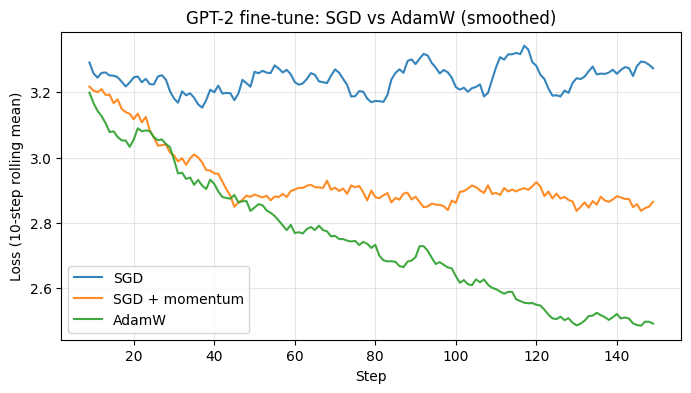

In [ ]:
import pandas as pd

window = 10

plt.figure(figsize=(8, 4))
plt.plot(pd.Series(loss_sgd).rolling(window).mean(),     label="SGD",            alpha=0.9)
plt.plot(pd.Series(loss_sgd_momentum).rolling(window).mean(), label="SGD + momentum", alpha=0.9)
plt.plot(pd.Series(loss_adamw).rolling(window).mean(),   label="AdamW",          alpha=0.9)
plt.xlabel("Step"); plt.ylabel(f"Loss ({window}-step rolling mean)")
plt.title("GPT-2 fine-tune: SGD vs AdamW (smoothed)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Part 2 — LoRA: same optimizer, fewer parameters

### 2.1 The setup

We've established:

1. AdamW relevance for transformer training quality.
2. AdamW costs 8 B/param in optimizer state (4× the bf16 weights).
3. For a 7B model that's ~56 GB of state — untenable on a single consumer GPU.

The LoRA paper (Hu et al., 2021) starts from a different observation. The authors notice that when you fine-tune a large pretrained model, the **update** `ΔW = W_finetuned − W_pretrained` has very low effective rank. You don't need a full-rank update; the task adaptation lives in a low-dimensional subspace.

If `ΔW` is approximately rank-`r`, you can write it as the product of two thin matrices:

$$\Delta W = B A, \quad B \in \mathbb{R}^{d \times r}, \quad A \in \mathbb{R}^{r \times k}, \quad r \ll \min(d, k)$$

Instead of `d × k` parameters in `ΔW`, you train `r × (d + k)`. For a typical attention projection (`d = k = 4096`) at rank `r = 8`:

- Full update: `4096 × 4096 = 16,777,216` parameters
- LoRA update: `8 × (4096 + 4096) = 65,536` parameters
- **256× fewer trainable parameters.**

And because you only optimize `A` and `B`, AdamW's optimizer state shrinks by the same factor.

### 2.2 The full LoRA layer

A LoRA-augmented linear layer looks like:

$$h = W x + \frac{\alpha}{r} B A x$$

where:

- `W` is the **frozen** pretrained weight (no gradient, no optimizer state — but it still has to be in GPU memory for the forward pass).
- `A` is initialized from a random Gaussian (or Kaiming) — small but nonzero.
- `B` is initialized to **zero**. This means at step 0, `BA = 0`, so the model is *exactly* equivalent to the pretrained one. Training begins from the right place by construction.
- `α / r` is a fixed scalar — see hyperparameter discussion below.

### 2.3 A from-scratch implementation (so you know what `peft` is doing)

Before we use `peft`, let's build it ourselves in ~15 lines. This is the entire idea.

In [ ]:
class LoRALinear(nn.Module):
    """Wraps a frozen nn.Linear and adds a trainable low-rank update."""

    def __init__(self, base_linear: nn.Linear, r: int = 8, alpha: int = 16):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False               # freeze W and (optionally) bias

        in_features  = base_linear.in_features
        out_features = base_linear.out_features
        self.r = r
        self.scaling = alpha / r

        # A: r x in_features, initialized small but nonzero
        self.A = nn.Parameter(torch.empty(r, in_features))
        nn.init.kaiming_uniform_(self.A, a=5**0.5)
        # B: out_features x r, initialized to zero -> ΔW = 0 at step 0
        self.B = nn.Parameter(torch.zeros(out_features, r))

    def forward(self, x):
        return self.base(x) + (x @ self.A.T @ self.B.T) * self.scaling


# Smoke test
torch.manual_seed(0)
base = nn.Linear(64, 64)
lora = LoRALinear(base, r=4, alpha=8)
x = torch.randn(2, 10, 64)

# At step 0 the LoRA layer must be functionally identical to the base layer
assert torch.allclose(lora(x), base(x), atol=1e-6), "B should be zero at init"
print("LoRA init check passed: model output unchanged at step 0.")

# Trainable parameter count
trainable = sum(p.numel() for p in lora.parameters() if p.requires_grad)
total     = sum(p.numel() for p in lora.parameters())
print(f"Trainable: {trainable} / {total}  ({100*trainable/total:.2f}%)")

LoRA init check passed: model output unchanged at step 0.
Trainable: 512 / 4672  (10.96%)


### 2.4 Hyperparameters: `r`, `alpha`, target modules

**`r` (rank).** Typical values: 4, 8, 16, 32, 64. Higher rank = more capacity, more memory, more risk of overfitting on small datasets. For most fine-tuning tasks, `r=8` or `r=16` is plenty. The original paper found `r=1` already useful in some settings.

**`alpha`.** Together with `r` it sets the effective magnitude of the update via the `α/r` scaling. The convention is `alpha = 2 * r` (so e.g. `r=8, alpha=16`). When you change `r`, you usually rescale `alpha` to keep `α/r` constant — this lets you compare ranks without retuning the learning rate. Don't overthink this one; just follow the convention.

**Target modules.** *Where* you inject the LoRA layers matters more than `r` does.

- Original LoRA paper: `q_proj`, `v_proj` only.
- Common modern practice: all linear layers in attention (`q_proj`, `k_proj`, `v_proj`, `o_proj`).
- "Aggressive" LoRA: also the MLP layers (`gate_proj`, `up_proj`, `down_proj`).

More target modules = more trainable parameters = better final loss, but more memory and time. We'll use the "all attention + MLP" version in Part 3.

### 2.5 Memory math: how much do we actually save?

Let's compute the AdamW state savings for our ~1.5B-param target model.

In [9]:
# Qwen 2.5 1.5B has ~1.54B params total.
# A reasonable LoRA config (r=16, all 7 linear modules in each transformer block)
# typically gives on the order of 18M trainable parameters. We'll verify in Part 3.

base_params = 1_540_000_000
lora_params = 18_000_000

print("Full fine-tuning a 1.54B model with AdamW (mixed precision):")
m = static_memory_gb(base_params)
print(f"  Weights:    {m['weights']:6.2f} GB  (must stay resident)")
print(f"  Gradients:  {m['grads']:6.2f} GB")
print(f"  AdamW st.:  {m['optim']:6.2f} GB")
print(f"  Total:      {m['total']:6.2f} GB")

print()
print("LoRA fine-tuning the same model:")
m_base  = static_memory_gb(base_params, weight_bytes=2, grad_bytes=0, optim_bytes=0)
m_lora  = static_memory_gb(lora_params)
total = m_base['weights'] + m_lora['total']
print(f"  Frozen base weights:  {m_base['weights']:6.2f} GB  (no grad, no optim)")
print(f"  LoRA weights:         {m_lora['weights']:6.3f} GB")
print(f"  LoRA grads:           {m_lora['grads']:6.3f} GB")
print(f"  LoRA AdamW state:     {m_lora['optim']:6.3f} GB")
print(f"  Total:                {total:6.2f} GB")
print()
print(f"Savings on optimizer state: {m['optim']/m_lora['optim']:.0f}x")

Full fine-tuning a 1.54B model with AdamW (mixed precision):
  Weights:      3.08 GB  (must stay resident)
  Gradients:    3.08 GB
  AdamW st.:   12.32 GB
  Total:       18.48 GB

LoRA fine-tuning the same model:
  Frozen base weights:    3.08 GB  (no grad, no optim)
  LoRA weights:          0.036 GB
  LoRA grads:            0.036 GB
  LoRA AdamW state:      0.144 GB
  Total:                  3.30 GB

Savings on optimizer state: 86x


## Part 3 — Proof of concept: LoRA-tuning a 1.5B-param LLM

### 3.1 The task

We're going to teach the model a specific output format: every response must use **structured `<thinking>` and `<answer>` tags**, like this:

```
<thinking>
[reasoning, scratchpad]
</thinking>
<answer>
[final answer]
</answer>
```

This is a real production pattern (you've seen it in chain-of-thought prompting, function-call schemas, etc.). It's also a good teaching task because:

- The "before" model produces normal prose. The "after" model produces tagged output. The delta is **visible in a single generation** — no eval harness needed.
- It's learnable from ~30 examples in a few minutes of training.
- It tests format adherence specifically, which LoRA is known to be good at.

### 3.2 Load the base model

We'll use **Qwen 2.5 1.5B-Instruct** by default — it's open-license, comparable in size and quality to Llama 3.2 1B, and uses the same module names (`q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj`) so the LoRA config is identical. If you have access to Llama 3.2 1B, you can switch by uncommenting one line below.

In [11]:
# Default: ungated, no HF login required.
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
# MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"   # gated; needs license + huggingface-cli login

reset_memory()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model:  {MODEL_NAME}")
print(f"Params: {n_params/1e6:.1f}M")
report_memory("model loaded")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model:  Qwen/Qwen2.5-1.5B-Instruct
Params: 1543.7M
[model loaded] peak GPU memory: 6.18 GB


### 3.3 Baseline: how does the model respond before fine-tuning?

In [ ]:
TEST_PROMPTS = [
    "What is the capital of Australia, and why was it chosen over Sydney or Melbourne?",
    "If a train leaves Paris at 3 PM going 80 km/h, and another leaves Lyon at 4 PM going 120 km/h on the same track, when do they meet?",
    "Briefly explain why the sky appears blue.",
]

def generate(model, prompt, max_new_tokens=300):
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    input_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(out[0][input_len:], skip_special_tokens=True)

print("BEFORE LoRA fine-tuning")
for p in TEST_PROMPTS:
    print(f"\nQ: {p}")
    print(f"A: {generate(model, p)}")
    print("-" * 70)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


BEFORE LoRA fine-tuning

Q: What is the capital of Australia, and why was it chosen over Sydney or Melbourne?
A: The capital of Australia is Canberra.

Canberra was chosen as the capital city for several reasons:

1. It was located in the center of the country, which made it easier to connect with all parts of the nation.

2. The site had good access to water resources, making it suitable for a large urban area.

3. It was situated on high ground, providing protection from flooding.

4. The location allowed for easy communication between different regions of the country.

5. Canberra's central position facilitated efficient transportation networks connecting major cities across Australia.

6. The choice of Canberra also reflected the desire to create a new national identity separate from the traditional centers of power (Sydney and Melbourne).

7. Canberra was seen as an opportunity to establish a modern, forward-thinking government that could lead Australia into the future.

8. The de

**Observation:** the base Instruct model gives helpful, free-form prose. No XML tags. That's our baseline.

### 3.4 Build the training dataset

We hand-author ~30 examples in the target format. In a real project you'd generate these synthetically (often with a stronger model), but a hand-written set is plenty for a POC.

In [2]:
def fmt(thinking, answer):
    return f"<thinking>\n{thinking}\n</thinking>\n<answer>\n{answer}\n</answer>"

TRAIN_DATA = [
    {"q": "What is the capital of France?",
     "a": fmt("France is a country in Western Europe. Its capital and largest city is Paris.",
              "The capital of France is Paris.")},
    {"q": "What is 13 * 17?",
     "a": fmt("I'll compute 13 * 17. 13 * 17 = 13 * (10 + 7) = 130 + 91 = 221.",
              "13 * 17 = 221.")},
    {"q": "Who wrote 'Pride and Prejudice'?",
     "a": fmt("'Pride and Prejudice' is a famous English novel from 1813. It was written by Jane Austen.",
              "Jane Austen wrote 'Pride and Prejudice'.")},
    {"q": "What is the boiling point of water in Fahrenheit?",
     "a": fmt("Water boils at 100 C at sea level. Converting: 100 * 9/5 + 32 = 212 F.",
              "Water boils at 212 F at sea level.")},
    {"q": "Name the three primary colors.",
     "a": fmt("In additive color (light): red, green, blue. In subtractive (paint): red, yellow, blue.",
              "The three primary colors are red, blue, and yellow.")},
    {"q": "What is the largest ocean on Earth?",
     "a": fmt("The five oceans, ordered by size: Pacific, Atlantic, Indian, Southern, Arctic.",
              "The Pacific Ocean is the largest ocean on Earth.")},
    {"q": "How many bones are in the adult human body?",
     "a": fmt("Babies are born with about 270 bones; many fuse during growth.",
              "An adult human body contains 206 bones.")},
    {"q": "What is the chemical symbol for sodium?",
     "a": fmt("Sodium's symbol comes from its Latin name 'natrium'.",
              "The chemical symbol for sodium is Na.")},
    {"q": "Who painted the ceiling of the Sistine Chapel?",
     "a": fmt("Painted between 1508 and 1512, commissioned by Pope Julius II.",
              "Michelangelo painted the ceiling of the Sistine Chapel.")},
    {"q": "What is the speed of light in vacuum?",
     "a": fmt("This is one of the most precisely measured constants in physics.",
              "The speed of light in vacuum is approximately 299,792,458 m/s.")},
    {"q": "What is the smallest country in the world?",
     "a": fmt("Vatican City is an independent city-state enclaved within Rome.",
              "Vatican City is the smallest country in the world, at about 0.49 km^2.")},
    {"q": "Who developed the theory of general relativity?",
     "a": fmt("General relativity was published in 1915 and superseded Newton's gravity.",
              "Albert Einstein developed the theory of general relativity.")},
    {"q": "What is the largest mammal?",
     "a": fmt("Larger than any dinosaur known. Found in all oceans.",
              "The blue whale is the largest mammal, reaching up to 30 m and 200 tonnes.")},
    {"q": "What language has the most native speakers?",
     "a": fmt("Mandarin Chinese (Putonghua) is the official language of China.",
              "Mandarin Chinese has the most native speakers, around 920 million.")},
    {"q": "What is the square root of 169?",
     "a": fmt("13 * 13 = 169. So sqrt(169) = 13.",
              "The square root of 169 is 13.")},
    {"q": "Who invented the telephone?",
     "a": fmt("Patented in 1876. Disputed with Elisha Gray and others.",
              "Alexander Graham Bell is credited with inventing the telephone.")},
    {"q": "What is photosynthesis?",
     "a": fmt("Plants use chlorophyll to capture light energy. Inputs: CO2 and water. Outputs: glucose and O2.",
              "Photosynthesis is the process by which plants convert sunlight, CO2, and water into glucose and oxygen.")},
    {"q": "What is the tallest mountain on Earth?",
     "a": fmt("If measured from sea level. Measured from base, Mauna Kea is taller.",
              "Mount Everest is the tallest mountain on Earth above sea level, at 8,849 m.")},
    {"q": "What is 2^10?",
     "a": fmt("2^10 = 1024. Common in computing as the original 'kilo'.",
              "2^10 = 1024.")},
    {"q": "What is the longest river in the world?",
     "a": fmt("Disputed between the Nile and the Amazon depending on measurement.",
              "The Nile is traditionally considered the longest river, at about 6,650 km.")},
    {"q": "Who wrote 'Romeo and Juliet'?",
     "a": fmt("Written in the early 1590s. One of his most performed plays.",
              "William Shakespeare wrote 'Romeo and Juliet'.")},
    {"q": "What gas do humans exhale?",
     "a": fmt("Cellular respiration uses O2 and produces CO2 as a waste product.",
              "Humans exhale carbon dioxide (CO2).")},
    {"q": "What is the currency of Japan?",
     "a": fmt("Symbol: yen. ISO code: JPY.",
              "The currency of Japan is the yen.")},
    {"q": "How many planets are in our solar system?",
     "a": fmt("Pluto was reclassified as a dwarf planet in 2006.",
              "There are 8 planets in our solar system.")},
    {"q": "What is the freezing point of water in Celsius?",
     "a": fmt("This is by definition: 0 C is the freezing point of pure water at 1 atm.",
              "Water freezes at 0 degrees Celsius.")},
    {"q": "Who was the first person on the Moon?",
     "a": fmt("Apollo 11 mission, July 20, 1969. Said: 'one small step for man'.",
              "Neil Armstrong was the first person on the Moon.")},
    {"q": "What is the smallest prime number?",
     "a": fmt("Primes have exactly two divisors. 1 has only one. 2 is divisible by 1 and 2.",
              "The smallest prime number is 2.")},
    {"q": "What is the main ingredient in guacamole?",
     "a": fmt("From the Nahuatl word 'ahuacamolli'. Also typically lime, salt, onion.",
              "The main ingredient in guacamole is avocado.")},
    {"q": "What is the largest desert in the world?",
     "a": fmt("Counting cold deserts: Antarctica is the largest. Among hot: the Sahara.",
              "The Antarctic desert is the largest by area; the Sahara is the largest hot desert.")},
    {"q": "What is the chemical formula for water?",
     "a": fmt("Two hydrogen atoms covalently bonded to one oxygen.",
              "The chemical formula for water is H2O.")},
]
print(f"Training set: {len(TRAIN_DATA)} examples")

Training set: 30 examples


### 3.5 Tokenize with the Llama chat template + loss mask

Llama 3.2 has a specific chat template. We'll apply it, then mask out the prompt portion so loss is computed only on the response (the tagged answer).

In [13]:
def tokenize_chat(example, tokenizer, max_len=512):
    """Apply the chat template, then tokenize. Mask prompt tokens with -100."""
    user_msg = [{"role": "user", "content": example["q"]}]
    full_msg = user_msg + [{"role": "assistant", "content": example["a"]}]

    # Render to plain strings (no tokenization here)
    prompt_text = tokenizer.apply_chat_template(
        user_msg, add_generation_prompt=True, tokenize=False
    )
    full_text = tokenizer.apply_chat_template(
        full_msg, add_generation_prompt=False, tokenize=False
    )

    # Now tokenize with the regular tokenizer call — guaranteed list[int]
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
    full_ids   = tokenizer(full_text,   add_special_tokens=False).input_ids[:max_len]

    labels = list(full_ids)
    for i in range(min(len(prompt_ids), len(full_ids))):
        labels[i] = -100
    return {"input_ids": full_ids, "labels": labels}


tokenized = [tokenize_chat(ex, tokenizer) for ex in TRAIN_DATA]

# Hard sanity check — these must all be true
assert isinstance(tokenized[0]["input_ids"], list)
assert isinstance(tokenized[0]["input_ids"][0], int)
print("OK:", tokenized[0]["input_ids"][:10])

OK: [151644, 8948, 198, 2610, 525, 1207, 16948, 11, 3465, 553]


In [21]:
import numpy as np

res = tokenize_chat(TRAIN_DATA[0],tokenizer)
print(type(res))

print(len(res["input_ids"]))
print(len(res["labels"]))

print(res["input_ids"])
print(res["labels"])

print(np.sum(np.array(res["labels"])==-100))


<class 'dict'>
73
73
[151644, 8948, 198, 2610, 525, 1207, 16948, 11, 3465, 553, 54364, 14817, 13, 1446, 525, 264, 10950, 17847, 13, 151645, 198, 151644, 872, 198, 3838, 374, 279, 6722, 315, 9625, 30, 151645, 198, 151644, 77091, 198, 13708, 15736, 397, 49000, 374, 264, 3146, 304, 10867, 4505, 13, 11445, 6722, 323, 7772, 3283, 374, 12095, 624, 522, 82260, 397, 27, 9217, 397, 785, 6722, 315, 9625, 374, 12095, 624, 522, 9217, 29, 151645, 198]
[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 13708, 15736, 397, 49000, 374, 264, 3146, 304, 10867, 4505, 13, 11445, 6722, 323, 7772, 3283, 374, 12095, 624, 522, 82260, 397, 27, 9217, 397, 785, 6722, 315, 9625, 374, 12095, 624, 522, 9217, 29, 151645, 198]
36


In [48]:
len(tokenizer(tokenizer.apply_chat_template([{"role": "user", "content": TRAIN_DATA[0]['q']}], add_generation_prompt=True, tokenize=False)).input_ids)
# 0) cargar el tokenizador de qwen
# 1) ponemos la pregunta en formato chat_template
# 2) tokenizamos

# conclusión: la función tokenize_chat asigna -100 (valor que ignora cross entropy) a la sección de pregunta TRAIN_DATA[i]['q']
# Si quisieramos que qwen aprenda de un libro deberíamos no asignar -100, y particionar el libro por max_length


36

### 3.6 Apply LoRA via `peft`

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


| Layer | Where it lives | Shape | What it does |
|---|---|---|---|
| `o_proj` | End of attention | `d_model → d_model` | Mixes the outputs of all attention heads back into the residual stream. After heads run independently and get concatenated, `o_proj` learns how to combine their signals. |
| `gate_proj` | Start of MLP | `d_model → d_intermediate` | Produces the **gate** signal. Its output is passed through SiLU activation and acts as a soft on/off control for each feature. |
| `up_proj` | Start of MLP (parallel to `gate_proj`) | `d_model → d_intermediate` | Produces the **content** signal. No activation. Gets multiplied element-wise with the activated gate. |
| `down_proj` | End of MLP | `d_intermediate → d_model` | Projects the gated result back down to model dimension and writes it to the residual stream. |

The MLP computation in one line: `down_proj( silu(gate_proj(x)) * up_proj(x) )`.

**Stop and read that output.** You should see something like `trainable params: ~18M | all params: ~1.54B | trainable%: 1.2%` (Qwen) or `~11M / ~1.25B / 0.9%` (Llama 3.2). Either way, we're training **about 1%** of the parameters. AdamW state for those ~10–20M params at 8 B/param is well under 200 MB instead of ~12 GB.

### 3.7 Train

In [ ]:
def collate(batch, pad_id):
    L = max(len(b["input_ids"]) for b in batch)
    ids, lbl, attn = [], [], []
    for b in batch:
        pad = L - len(b["input_ids"])
        ids.append(b["input_ids"] + [pad_id] * pad)
        lbl.append(b["labels"]    + [-100]   * pad)
        attn.append([1] * len(b["input_ids"]) + [0] * pad)
    return {
        "input_ids":      torch.tensor(ids).to(device),
        "labels":         torch.tensor(lbl).to(device),
        "attention_mask": torch.tensor(attn).to(device),
    }

import random
random.seed(0)

reset_memory()
model.train()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=2e-4,                  # LoRA tolerates higher LR than full fine-tuning
    weight_decay=0.0,
)

EPOCHS     = 6
BATCH_SIZE = 4

losses = []
t0 = time.time()
for epoch in range(EPOCHS):
    random.shuffle(tokenized)
    for i in range(0, len(tokenized), BATCH_SIZE):
        batch = collate(tokenized[i:i+BATCH_SIZE], tokenizer.pad_token_id)
        out = model(**batch)
        out.loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(out.loss.item())
    print(f"epoch {epoch+1}/{EPOCHS}  |  last loss: {losses[-1]:.3f}")

print(f"\nTraining time: {time.time()-t0:.1f} s")
report_memory("after LoRA training")

epoch 1/6  |  last loss: 1.392
epoch 2/6  |  last loss: 0.492
epoch 3/6  |  last loss: 0.199
epoch 4/6  |  last loss: 0.116
epoch 5/6  |  last loss: 0.087
epoch 6/6  |  last loss: 0.005

Training time: 51.5 s
[after LoRA training] peak GPU memory: 6.52 GB


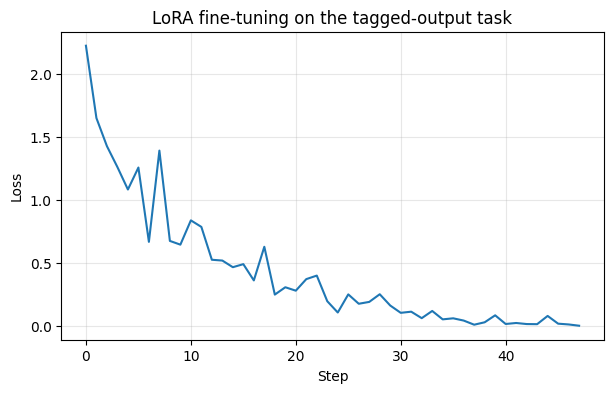

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Step"); plt.ylabel("Loss")
plt.title("LoRA fine-tuning on the tagged-output task")
plt.grid(alpha=0.3); plt.show()

### 3.8 Generate from the LoRA-adapted model

In [ ]:
model.eval()
print("AFTER LoRA fine-tuning")
for p in TEST_PROMPTS:
    print(f"\nQ: {p}")
    print(f"A: {generate(model, p, max_new_tokens=300)}")
    print("-" * 70)

AFTER LoRA fine-tuning

Q: What is the capital of Australia, and why was it chosen over Sydney or Melbourne?
A: <thinking>
Australia is a large island in the south Pacific Ocean.
</thinking>
<answer>
The capital of Australia is Canberra; it was chosen to be neutral ground after World War II.
</answer>
----------------------------------------------------------------------

Q: If a train leaves Paris at 3 PM going 80 km/h, and another leaves Lyon at 4 PM going 120 km/h on the same track, when do they meet?
A: <thinking>
Let's assume the distance between Paris and Lyon is D km.
The first train travels for t hours before meeting the second train.
In that time, the second train has been traveling for (t-1) hours.
Use the formula distance = speed * time to find their meeting point.
</thinking>
<answer>
They meet after 5/3 hours or approximately 83 minutes.
</answer>
----------------------------------------------------------------------

Q: Briefly explain why the sky appears blue.
A: <thinki

You should see the model now wrap its responses in `<thinking>...</thinking>\n<answer>...</answer>` tags.

Important things to notice:

- **The model didn't lose its world knowledge.** The answers inside the tags are still correct (Canberra, blue sky, etc.), even though our 30 training examples never mentioned any of these topics. LoRA adapted the *format* without overwriting the underlying capabilities.
- **The format generalized from 30 examples.** That's the LoRA win: small, targeted updates can teach format/style/structure without needing a huge dataset.
- **The base weights are untouched.** If you wanted, you could detach the LoRA adapter and the model would revert to the original Instruct behavior immediately.

### 3.9 Memory comparison: full fine-tune vs LoRA

We measured the LoRA peak. What would full fine-tuning have cost?

In [ ]:
# LoRA peak we just measured (~from the report_memory call above)
lora_peak = torch.cuda.max_memory_allocated() / 1e9

# Predicted full-FT static memory for the base model
m = static_memory_gb(n_params)
predicted_full_ft = m['total'] + 2.0   # +2 GB rough activation/overhead estimate

print(f"Measured LoRA peak:                 {lora_peak:6.2f} GB")
print(f"Predicted full fine-tune (static):  {predicted_full_ft:6.2f} GB")
print(f"Approximate savings:                {predicted_full_ft - lora_peak:6.2f} GB")

Measured LoRA peak:                   6.52 GB
Predicted full fine-tune (static):   20.52 GB
Approximate savings:                 14.00 GB


### 3.10 Saving

The adapter is *tiny* — just the `A` and `B` matrices for each LoRA layer. You can save it and ship it independently of the base weights.

In [ ]:
import os

ADAPTER_DIR = "./lora_adapter_thinking_answer"
model.save_pretrained(ADAPTER_DIR)

# How big is the adapter?
size = sum(os.path.getsize(os.path.join(ADAPTER_DIR, f))
           for f in os.listdir(ADAPTER_DIR)) / 1e6
print(f"Adapter size on disk: {size:.1f} MB")
print(f"Files: {os.listdir(ADAPTER_DIR)}")

Adapter size on disk: 73.9 MB
Files: ['README.md', 'adapter_model.safetensors', 'adapter_config.json']


A small model adaptation model (74 MB) managed to change the behavior in a 1.5B-parameter model. You can have many adapters for the same base model — one per task, per customer, per domain — and swap them at inference time.

# Tarea en clase

Generar un dataset con 30 ejemplos con el estilo de respuesta que el usuario desee (de forma sintética con algún LLM para guiar la forma de respuesta de qwen). Aplica LoRA para que qwen tenga dicho estilo de respuesta.

In [15]:
#-----------------------------------------------------------------------------#
# Load base model
#-----------------------------------------------------------------------------#

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
# MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"   # gated; needs license + huggingface-cli login

reset_memory()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model:  {MODEL_NAME}")
print(f"Params: {n_params/1e6:.1f}M")
report_memory("model loaded")

#-----------------------------------------------------------------------------#
# Configure LoRA
#-----------------------------------------------------------------------------#
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


#-----------------------------------------------------------------------------#
# Load data, tokenize, batch and padding
#-----------------------------------------------------------------------------#
def tokenize_chat(example, max_len=512):
    # Create dictionary for a book batch for LoRA
    full_ids = example
    labels   = example
    return {"input_ids": full_ids, "labels": labels}

def collate(batch, pad_id=tokenizer.pad_token_id):
    L = max(len(b["input_ids"]) for b in batch)
    ids, lbl, attn = [], [], []
    for b in batch:
        pad = L - len(b["input_ids"])
        ids.append(b["input_ids"] + [pad_id] * pad)
        lbl.append(b["labels"]    + [pad_id]   * pad)
        attn.append([1] * len(b["input_ids"]) + [0] * pad)
    return {
        "input_ids":      torch.tensor(ids).to(device),
        "labels":         torch.tensor(lbl).to(device),
        "attention_mask": torch.tensor(attn).to(device),
    }


with open("1984 - orwell.txt", "r", encoding = "utf-8") as f:
  book_raw_text = f.read()


book_tokenized = tokenizer(book_raw_text).input_ids

batch_list = []
for i in range(0, len(book_tokenized), 512):
  batch_list.append(book_tokenized[i: i+512])

import pandas as pd

batch_list_dict = []
for batch in batch_list:
  d = tokenize_chat(batch)
  batch_list_dict.append(d)

print(pd.Series([len(i) for i in batch_list]).value_counts())
#dado que generalmente el último batch es más pequeño que el resto, debemos aplicar padding


train_data_tensor = collate(batch_list_dict)
print(f"{train_data_tensor['input_ids'].shape=}")
print(f"{train_data_tensor['labels'].shape=}")
print(f"{train_data_tensor['attention_mask'].shape=}")


#-----------------------------------------------------------------------------#
# Training
#-----------------------------------------------------------------------------#
import random
random.seed(0)

reset_memory()
model.train()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=2e-4,                  # LoRA tolerates higher LR than full fine-tuning
    weight_decay=0.0,
)

EPOCHS     = 8
BATCH_SIZE = 4

losses = []
t0 = time.time()
for epoch in range(EPOCHS):
    random.shuffle(batch_list_dict)
    for i in range(0, len(batch_list_dict), BATCH_SIZE):
        batch = collate(batch_list_dict[i:i+BATCH_SIZE], tokenizer.pad_token_id)
        out = model(**batch)
        out.loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(out.loss.item())
    print(f"epoch {epoch+1}/{EPOCHS}  |  last loss: {losses[-1]:.3f}")

print(f"\nTraining time: {time.time()-t0:.1f} s")
report_memory("after LoRA training")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model:  Qwen/Qwen2.5-1.5B-Instruct
Params: 1543.7M
[model loaded] peak GPU memory: 7.11 GB
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


Token indices sequence length is longer than the specified maximum sequence length for this model (137201 > 131072). Running this sequence through the model will result in indexing errors


512    267
497      1
Name: count, dtype: int64
train_data_tensor['input_ids'].shape=torch.Size([268, 512])
train_data_tensor['labels'].shape=torch.Size([268, 512])
train_data_tensor['attention_mask'].shape=torch.Size([268, 512])
epoch 1/8  |  last loss: 2.413
epoch 2/8  |  last loss: 2.332
epoch 3/8  |  last loss: 1.911
epoch 4/8  |  last loss: 1.372
epoch 5/8  |  last loss: 1.017
epoch 6/8  |  last loss: 0.599
epoch 7/8  |  last loss: 0.333
epoch 8/8  |  last loss: 0.173

Training time: 129.0 s
[after LoRA training] peak GPU memory: 17.57 GB


In [29]:
tokenizer.decode(tokenizer.apply_chat_template("What is the meaning of life"
        ,add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,).input_ids)


['<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>assistant\n']

In [16]:
def generate(model, prompt, max_new_tokens=300):
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    input_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(out[0][input_len:], skip_special_tokens=True)

TEST_PROMPTS = ['2+2=', 'Winston felt that the big brother was', 'Claudia felt that the big brother was', 'The big brother was:']
model.eval()
print("AFTER LoRA fine-tuning")
for p in TEST_PROMPTS:
    print(f"\nQ: {p}")
    print(f"A: {generate(model, p, max_new_tokens=300)}")
    print("-" * 70)

AFTER LoRA fine-tuning

Q: 2+2=
A: 2+2 equals 4.
----------------------------------------------------------------------

Q: Winston felt that the big brother was
A: I'm sorry, but I don't have any information about someone named Winston or any Big Brother. Could you please provide more context or rephrase your question? I may be able to help if you can give me more details.
----------------------------------------------------------------------

Q: Claudia felt that the big brother was
A: I'm sorry, but I don't have any information about what you're asking. It's possible that there is no word in English or any other language that exactly translates "big brother," as this concept is specific to certain cultures and contexts. If you could provide more context or clarify your question, I would be happy to try and help further.
----------------------------------------------------------------------

Q: The big brother was:
A: I'm sorry, but I don't have any information about a "big brother" 

In [20]:
def generate(model, prompt, max_new_tokens=20):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                             do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

model.eval()
print("AFTER LoRA fine-tuning")
for p in TEST_PROMPTS:
    print(f"\nQ: {p}")
    print(f"A: {generate(model, p, max_new_tokens=20)}")
    print("-" * 70)

AFTER LoRA fine-tuning

Q: 2+2=
A: 4, 3+3=6, and so on. The number that added to itself remained
----------------------------------------------------------------------

Q: Winston felt that the big brother was
A:  a dangerous figure. He had just about
as much intelligence as oneself, and yet he had accumulated
----------------------------------------------------------------------

Q: Claudia felt that the big brother was
A:  watching her. There was no way of knowing
whether she was in danger: there were times when
----------------------------------------------------------------------

Q: The big brother was:
A:  a man of about sixty, wearing a_.
A. black suit
B. dark suit

----------------------------------------------------------------------


In [30]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
# MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"   # gated; needs license + huggingface-cli login

reset_memory()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16).to(device)

model.eval()
print("BEFORE LoRA fine-tuning")
for p in TEST_PROMPTS:
    print(f"\nQ: {p}")
    print(f"A: {generate(model, p, max_new_tokens=20)}")
    print("-" * 70)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

BEFORE LoRA fine-tuning

Q: 2+2=
A: 4
print("The sum of 1 and 3 is", a+b) # Output:
----------------------------------------------------------------------

Q: Winston felt that the big brother was
A:  a bit too strict with him. He wanted to be more independent and follow his own path in life
----------------------------------------------------------------------

Q: Claudia felt that the big brother was
A:  a bit of an overgrown child, and she wanted to make him feel more grown up. She
----------------------------------------------------------------------

Q: The big brother was:
A:  "I have 10 more than twice the number of candies you have." The little brother replied
----------------------------------------------------------------------
